In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
import tensorflow as tf
from darts.utils.statistics import check_seasonality
from darts import TimeSeries

import torch
import torch.nn as nn

from typing import Literal

In [61]:
%load_ext autoreload
%autoreload 2

from slrp_ev_data.read_old_data import read_old_data
from slrp_ev_data.train_test_split import train_test_split
from slrp_ev_data.window_generator import WindowGenerator

from slrp_ev_data.feature_engineering import (feature_engineering, reverse_feature_engineering,
                                              get_train_mean_and_std, get_train_min_and_max)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Compare old and new data

### Read old data

In [62]:
df_old = read_old_data()
df_old

,date,power,workday
0,2022-01-01 00:00:00,0.0,0
1,2022-01-01 00:15:00,0.0,0
2,2022-01-01 00:30:00,0.0,0
3,2022-01-01 00:45:00,0.0,0
4,2022-01-01 01:00:00,0.0,0
...,...,...,...
77947,2024-03-22 22:45:00,-0.0,1
77948,2024-03-22 23:00:00,-0.0,1
77949,2024-03-22 23:15:00,-0.0,1
77950,2024-03-22 23:30:00,-0.0,1


### Read new data

In [67]:
df_new = pd.read_csv("power_df_2008-2406_v240828.csv", index_col=0)
df_new["recordTimestamp"] = pd.to_datetime(
    df_new["recordTimestamp"], utc=True
).dt.tz_convert("America/Los_Angeles")

df_new

,recordTimestamp,siteId,activeStationIds,totalPower,numberOfActiveSessions,fractionOfRegularSessions,averageRegularPricePerHour,averageScheduledPricePerHour,power1,power2,...,dcosId6,dcosId7,dcosId8,isArtificialData,dayNumber,isWeekend,weekNumber,isHoliday,sch_centsPerHr,reg_centsPerHr
0,2020-08-18 18:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
1,2020-08-18 18:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
2,2020-08-18 18:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
3,2020-08-18 18:45:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
4,2020-08-18 18:50:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,34,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400991,2024-06-11 02:25:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400992,2024-06-11 02:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400993,2024-06-11 02:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,1,False,24,False,NaN,NaN
400994,2024-06-11 02:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,True,1,False,24,False,NaN,NaN


### Visualization old vs new

In [5]:
start_date = pd.Timestamp("2023-09-25", tz="America/Los_Angeles")
end_date = pd.Timestamp("2023-09-30", tz="America/Los_Angeles")

number_of_time_ticks = 12

In [6]:
# create the subframe
sub_power_df_old = df_old.query(
    f"recordTimestamp >= '{start_date}' and recordTimestamp <= '{end_date}'"
).copy()
sub_power_df_new = df_new.query(
    f"recordTimestamp >= '{start_date}' and recordTimestamp <= '{end_date}'"
).copy()

# Plot the graph

fig, ax1 = plt.subplots(figsize=(7, 4))
# ax2 = ax1.twinx()
ax1.plot(
    sub_power_df_old["recordTimestamp"],
    sub_power_df_old["totalPower"],
    color="blue",
    label="Old data built from session info",
)
ax1.plot(
    sub_power_df_new["recordTimestamp"],
    sub_power_df_new["totalPower"],
    color="green",
    label="New data built from power readings",
)
ax1.set_ylabel("Power (W)")
ax1.set_ylim(0, 65000)
# # add background color for weekends and public holidays
# ax1.bar(
#     sub_power_df_old["recordTimestamp"],
#     70000 * (sub_power_df_old["isWeekend"] + sub_power_df_old["isHoliday"]),
#     width=pd.Timedelta("5Min"),
#     align="edge",
#     color="lightgrey",
#     alpha=0.5,
#     label="Weekend or Holiday",
# )
# # add background color for missing data
# ax1.bar(
#     sub_power_df_old["recordTimestamp"],
#     70000 * sub_power_df_old["isArtificialData"],
#     width=pd.Timedelta("5Min"),
#     align="edge",
#     color="red",
#     alpha=0.3,
#     label="Missing Data",
# )

# Customize the plot

plt.title("Power Readings Over Time")


# set the time ticks
desired_frequencies = [2, 4, 6, 12, 24, 48, 96, 168, 336, 720, 1440]
x_axis_freq = int(
    (end_date - start_date).total_seconds() / 3600 // number_of_time_ticks
)
# Select the desired frequency that is closest to but not greater than the initial frequency
x_axis_freq = max([freq for freq in desired_frequencies if freq <= x_axis_freq * 1.3])
print(
    f"Using x-axis frequency of {x_axis_freq} hours in order to display around {number_of_time_ticks} ticks."
)
x_axis_freq = f"{x_axis_freq}h"
ax1.set_xlim(start_date, end_date)

ax1.set_xticks(
    pd.date_range(start_date, end_date, freq=x_axis_freq, tz="America/Los_Angeles")
)

ax1.set_xticklabels(
    pd.date_range(
        start_date, end_date, freq=x_axis_freq, tz="America/Los_Angeles"
    ).strftime("%y-%m-%d %Hh"),
    rotation=75,
)
ax1.set_xlabel("Timestamp")

ax1.legend(bbox_to_anchor=(0, -0.4), loc="upper left", borderaxespad=0)
plt.grid(True)
fig.subplots_adjust(bottom=0.1)

# Show the plot

plt.show()

UndefinedVariableError: name 'recordTimestamp' is not defined

# Data Analysis

## Fourrier analysis for best time frequencies

Fourrier analysis can be used to identify the frequencies of the data, i.e. the most important time features.
See reference [here](https://www.tensorflow.org/tutorials/structured_data/time_series#time)

In [6]:
import tensorflow as tf
import numpy as np

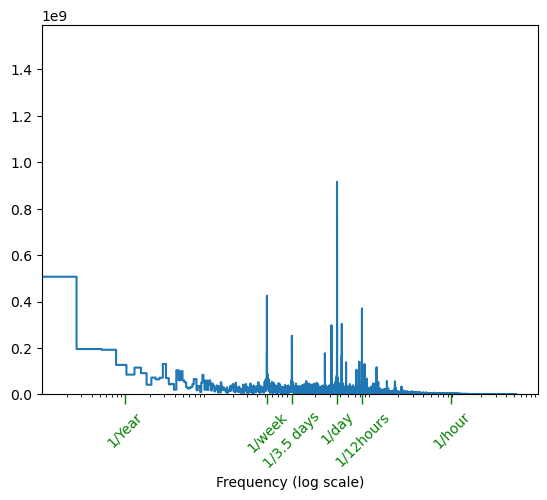

In [9]:
fft = tf.signal.rfft(df_new["totalPower"].fillna(0))
f_per_dataset = np.arange(0, len(fft))

n_samples_5min = len(df_new["totalPower"])
intervals_5min_per_hour = 60 // 5
hours_per_year = 24 * 365.2524
years_per_dataset = n_samples_5min / (hours_per_year * intervals_5min_per_hour)

f_per_year = f_per_dataset / years_per_dataset
fig, ax = plt.subplots()
ax.step(f_per_year, np.abs(fft))
ax.set_xscale("log")
ax.set_ylim([0, max(plt.ylim())])
ax.set_xlim([0.1, max(plt.xlim())])
ax.set_xticks(
    [
        1,
        365.2524 / 7,
        365.2524 / 3.5,
        365.2524,
        365.2524 * 2,
        hours_per_year,
    ],
    labels=["1/Year", "1/week", "1/3.5 days", "1/day", "1/12hours", "1/hour"],
    rotation=45,
)
ax.tick_params(axis="x", colors="green", width=1, length=7)
_ = ax.set_xlabel("Frequency (log scale)")
plt.show()

As shown on the figure above, the most important frequencies are the week and the day (2 highest peaks). This means that important features are the time of the week (day of the week) and the time od the day (hour). Features like the time of the year (week number) or the time of the hour do not seem that important.

### Fourrier on old data

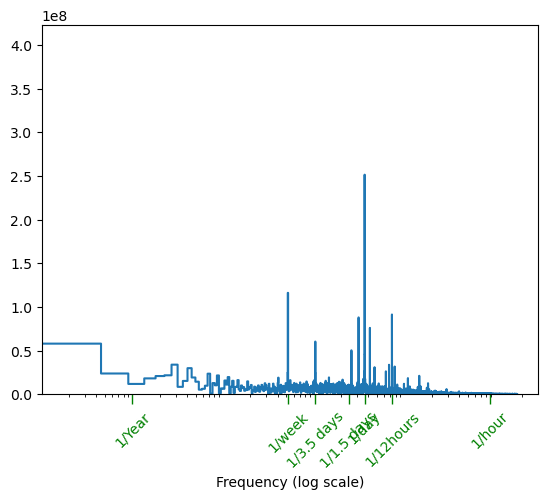

In [14]:
fft = tf.signal.rfft(df_old["power"].fillna(0))
f_per_dataset = np.arange(0, len(fft))

n_samples_15min = len(df_old["power"])
intervals_15min_per_hour = 60 // 15
hours_per_year = 24 * 365.2524
years_per_dataset = n_samples_15min / (hours_per_year * intervals_15min_per_hour)

f_per_year = f_per_dataset / years_per_dataset
fig, ax = plt.subplots()
ax.step(f_per_year, np.abs(fft))
ax.set_xscale("log")
ax.set_ylim([0, max(plt.ylim())])
ax.set_xlim([0.1, max(plt.xlim())])
ax.set_xticks(
    [
        1,
        365.2524 / 7,
        365.2524 / 3.5,
        365.2524 / 1.5,
        365.2524,
        365.2524 * 2,
        hours_per_year,
    ],
    labels=[
        "1/Year",
        "1/week",
        "1/3.5 days",
        "1/1.5 days",
        "1/day",
        "1/12hours",
        "1/hour",
    ],
    rotation=45,
)
ax.tick_params(axis="x", colors="green", width=1, length=7)
_ = ax.set_xlabel("Frequency (log scale)")
plt.show()

## Analyze lags correlation

The following test ensures that the data is stationary. Stationary is *required* because it is an assumption of the statistical models. To make data stationary, we can use differentiation.

In [69]:
from statsmodels.tsa.stattools import adfuller


def check_stationarity(series):
    # Copied from https://machinelearningmastery.com/time-series-data-stationary-python/

    result = adfuller(series.values)

    print("ADF Statistic: %f" % result[0])
    print("p-value: %f" % result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print("\t%s: %.3f" % (key, value))

    if (result[1] <= 0.05) & (result[4]["5%"] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")


print("Checking stationarity of old data:")
check_stationarity(df_old["power"])
print("Checking stationarity of new data:")
check_stationarity(df_new["totalPower"].fillna(0))

Checking stationarity of old data:
ADF Statistic: -28.266034
p-value: 0.000000
Critical Values:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Stationary
Checking stationarity of new data:
ADF Statistic: -54.172637
p-value: 0.000000
Critical Values:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Stationary


The lue area in the ACF and PACF plots, which depicts the 95% confidence interval and is in indicator for the significance threshold. That means, anything within the blue area is statistically close to zero and anything outside the blue area is statistically non-zero.

- If there are several autocorrelation lags that are significantly non-zero (ACF), the time series is non-random.
- The significant lags (outside blue area) of the PACF mean that we data is autoregressive (could be a linear combination of all those lags)
- The significant lags (outside blue area) of the ACF mean that we can build a moving average model

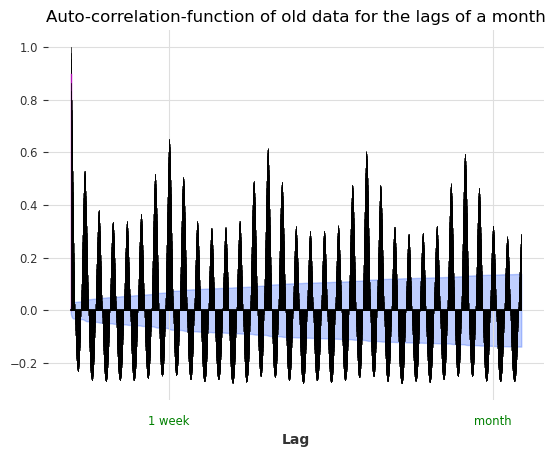

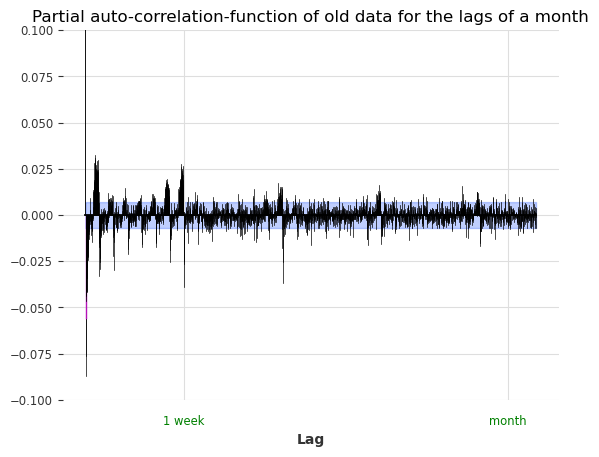

In [4]:
from darts.utils.statistics import plot_acf, plot_pacf

series = TimeSeries.from_dataframe(df_old, time_col="date", value_cols="power")


fig, ax = plt.subplots()


plot_acf(series, m=4, alpha=0.05, max_lag=96 * 32, axis=ax)
ax.set_title("Auto-correlation-function of old data for the lags of a month")
# add ticks for 1 week and 1 month
ax.set_xticks(
    [96 * 7, 96 * 30],
    labels=["1 week", "month"],
)
ax.tick_params(axis="x", colors="green", width=1, length=7)
ax.set_xlabel("Lag")
plt.show()

fig, ax = plt.subplots()
plot_pacf(series, m=4, alpha=0.05, max_lag=96 * 32, axis=ax)
ax.set_title("Partial auto-correlation-function of old data for the lags of a month")
# add ticks for 1 week and 1 month
ax.set_xticks(
    [96 * 7, 96 * 30],
    labels=["1 week", "month"],
)
ax.tick_params(axis="x", colors="green", width=1, length=7)
ax.set_xlabel("Lag")
ax.set_ylim(-0.1, 0.1)
plt.show()

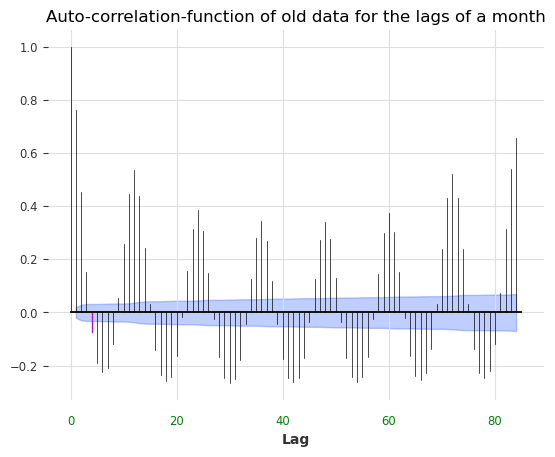

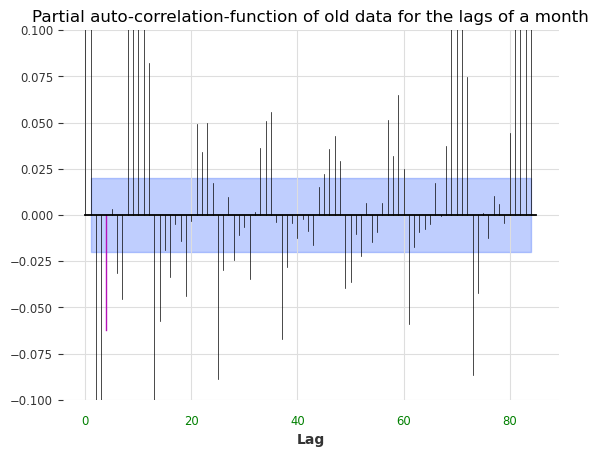

In [29]:
from darts.utils.statistics import plot_acf, plot_pacf

series = TimeSeries.from_dataframe(df_old, time_col="date", value_cols="power")


fig, ax = plt.subplots()


plot_acf(series.resample("2h"), m=4, alpha=0.05, max_lag=int(96 / 8 * 7), axis=ax)
ax.set_title("Auto-correlation-function of old data for the lags of a month")

ax.tick_params(axis="x", colors="green", width=1, length=7)
ax.set_xlabel("Lag")
plt.show()

fig, ax = plt.subplots()
plot_pacf(series.resample("2h"), m=4, alpha=0.05, max_lag=int(96 / 8 * 7), axis=ax)
ax.set_title("Partial auto-correlation-function of old data for the lags of a month")

ax.tick_params(axis="x", colors="green", width=1, length=7)
ax.set_xlabel("Lag")
ax.set_ylim(-0.1, 0.1)
plt.show()

## Distribution of monthly peak power

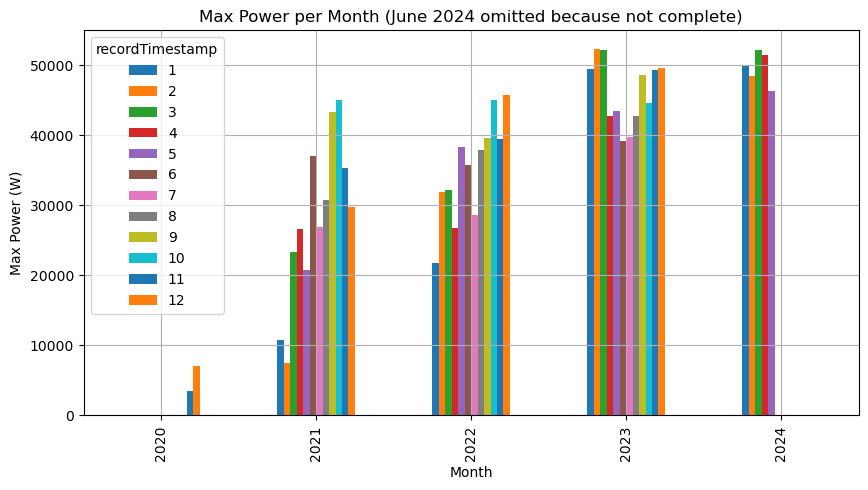

In [25]:
# show max power for each month for each year
# June 2024 is omitted because not complete
monthly_max_power = (
    df_new[df_new["recordTimestamp"] < "2024-06-01"]
    .groupby([df_new["recordTimestamp"].dt.year, df_new["recordTimestamp"].dt.month])[
        "totalPower"
    ]
    .max()
)

# plot distribution of max monthly power, with a different color for each year
fig, ax = plt.subplots(figsize=(10, 5))
monthly_max_power.unstack().plot(kind="bar", ax=ax)
ax.set_ylabel("Max Power (W)")
ax.set_xlabel("Month")
ax.set_title("Max Power per Month (June 2024 omitted because not complete)")
plt.grid(True)
plt.show()

### Distribution of when the peaks occur (hour)

In [127]:
choice_mode_distribution: Literal["peak_power", "peak_hour", "peak_day_of_week"] = (
    "peak_power"
)
frequency_distribution: Literal["each_month", "each_year"] = "each_year"

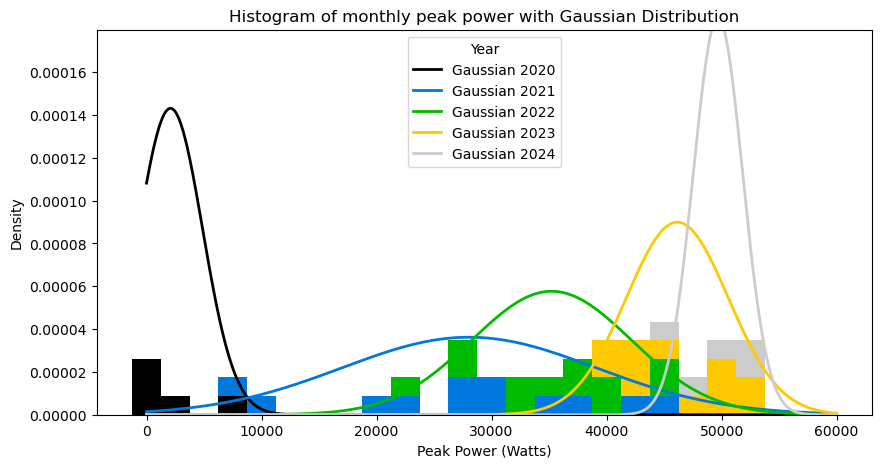

In [129]:
# get power grouped for each month for each year
# June 2024 is omitted because not complete
mask = df_new["recordTimestamp"] < "2024-06-01"
if frequency_distribution == "each_month":
    mask = mask & (df_new["recordTimestamp"].dt.year > 2020)
df_for_each_year_month = (
    df_new[mask]
    .groupby([df_new["recordTimestamp"].dt.year, df_new["recordTimestamp"].dt.month])[
        "totalPower"
    ]
)
if choice_mode_distribution == "peak_power":
    df_for_each_year_month = df_for_each_year_month.max()
elif choice_mode_distribution == "peak_day_of_week":
    df_for_each_year_month = df_for_each_year_month.idxmax().apply(lambda x: df_new.loc[x, "recordTimestamp"].day_of_week)
elif choice_mode_distribution == "peak_hour":
    df_for_each_year_month = df_for_each_year_month.idxmax().apply(lambda x: df_new.loc[x, "recordTimestamp"].hour)
    

fig, ax = plt.subplots(figsize=(10, 5))

if choice_mode_distribution == "peak_day_of_week":
    max_x_axis = 7
    bin_size = 1
elif choice_mode_distribution == "peak_hour":
    max_x_axis = 23
    bin_size = 1
elif choice_mode_distribution == "peak_power":
    max_x_axis = 60000
    bin_size = 2500
# Define the bin edges
bin_edges = np.arange(0, max_x_axis, bin_size) - bin_size/2
x = np.linspace(0, max_x_axis, 1000)  # Define the x range for the PDF

df_for_each_year_month = df_for_each_year_month.unstack()
if frequency_distribution == "each_month":
    df_for_each_year_month = df_for_each_year_month.transpose()


colors = plt.cm.nipy_spectral(
    np.linspace(0, 1, len(df_for_each_year_month.index))
)  # Generate a color for each year

ax.hist(
    [df_for_each_year_month.loc[year] for year in df_for_each_year_month.index],
    bins=bin_edges,  # Use the defined bin edges
    color=colors,
    alpha=1,
    stacked=True,
    density=True,  # Normalize the histogram
    align='mid'  # Center the bars on the ticks
)

y_max_list = []
for color, year in zip(colors, df_for_each_year_month.index):
    # here "year" can refer to year or month, depending on frequence_distribution
    data = df_for_each_year_month.loc[year].dropna()

    # ax.hist(
    #     df_for_each_year_month.loc[year],
    #     bins=bin_edges,  # Use the defined bin edges
    #     color=color,
    #     alpha=0.5,
    #     label=year,
    #     density=True,  # Normalize the histogram
    # )

    # Fit a normal distribution to the data
    mu, std = norm.fit(data)
    
    # Plot the PDF
    std = max(std, 0.01) # 0.01 is a small number to avoid division by zero
    p = norm.pdf(x, mu, std)
    y_max_list.append(max(p))
    ax.plot(x, p, linewidth=2, color=color, label=f"Gaussian {year}")

ax.set_ylim(0, np.median(y_max_list) * 2) # set y limit to 1.5 times the median of the maximum y value of the gaussian curves, so that the gaussian curves are all visible
if choice_mode_distribution == "peak_day_of_week":
    ax.set_xlabel("Day of the week of the peak")
elif choice_mode_distribution == "peak_hour":
    ax.set_xlabel("Hour of the peak")
elif choice_mode_distribution == "peak_power":
    ax.set_xlabel("Peak Power (Watts)")

ax.set_ylabel("Density")
if frequency_distribution == "each_year":
    ax.legend(title="Year")
elif frequency_distribution == "each_month":
    ax.legend(title="Month")
plt.title(f"Histogram of monthly {choice_mode_distribution.replace("_", " ")} with Gaussian Distribution")
plt.show()

## Load Curve

In [74]:
# Parameters
split_by_year: bool = True

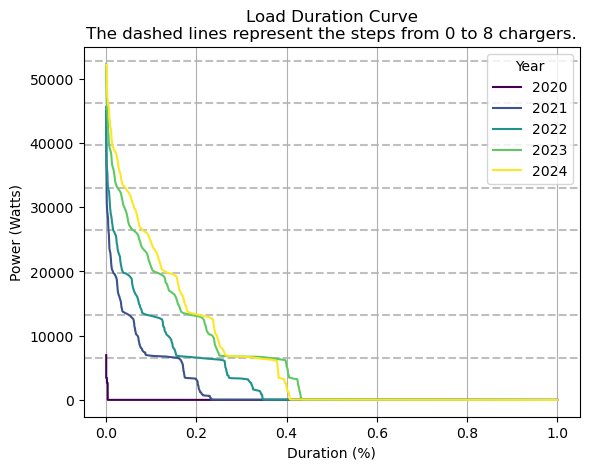

In [76]:
def get_load_duration_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Define the bin edges
    bins = np.linspace(
        df["totalPower"].min() - 0.001, df["totalPower"].max(), 1000
    )  # Adjust the number of bins as needed

    # Use pandas.cut to bin the data into intervals
    df["bin"] = pd.cut(df["totalPower"], bins=bins)

    # Use value_counts to count the frequency of each bin
    histogram = df["bin"].value_counts().sort_index()

    # Convert the histogram to a DataFrame
    histogram = pd.DataFrame({"bin": histogram.index, "frequency": histogram.values})
    histogram["bin"] = histogram["bin"].apply(lambda x: round(x.left))

    histogram = histogram.sort_values(by="bin", ascending=False)

    histogram["cumulative_frequency"] = (
        histogram["frequency"].cumsum() / histogram["frequency"].sum()
    )

    return histogram


fig, ax = plt.subplots()

colors = plt.cm.viridis(
    np.linspace(0, 1, len(df_new["recordTimestamp"].dt.year.unique()))
)
if split_by_year:
    for group_iter, color in zip(
        df_new.groupby(df_new["recordTimestamp"].dt.year), colors
    ):
        name, group = group_iter
        histogram = get_load_duration_df(group)
        ax.plot(
            histogram["cumulative_frequency"],
            histogram["bin"],
            label=name,
            color=color,
        )
        ax.legend(title="Year")
else:
    histogram = get_load_duration_df(df_new)
    ax.plot(histogram["cumulative_frequency"], histogram["bin"])


# plot a dash line at the power value of x chargers
total_number_of_chargers_to_show = 8
for charger_number in range(1, total_number_of_chargers_to_show + 1):
    ax.axhline(
        y=charger_number * 6600,
        color="gray",
        alpha=0.5,
        linestyle="--",
        zorder=-1,  # This ensures the line is plotted behind existing elements
    )
ax.set_xlabel("Duration (%)")
ax.set_ylabel("Power (Watts)")
ax.set_title(
    f"Load Duration Curve\nThe dashed lines represent the steps from 0 to {total_number_of_chargers_to_show} chargers."
)

ax.grid(True, axis="x")

## Heatmap of peak distribution

In [4]:
power_mode: Literal["max", "mean"] = "mean"
frequency_mode: Literal["hour_of_day", "day_of_week"] = "hour_of_day"
color_code = "YlOrRd"

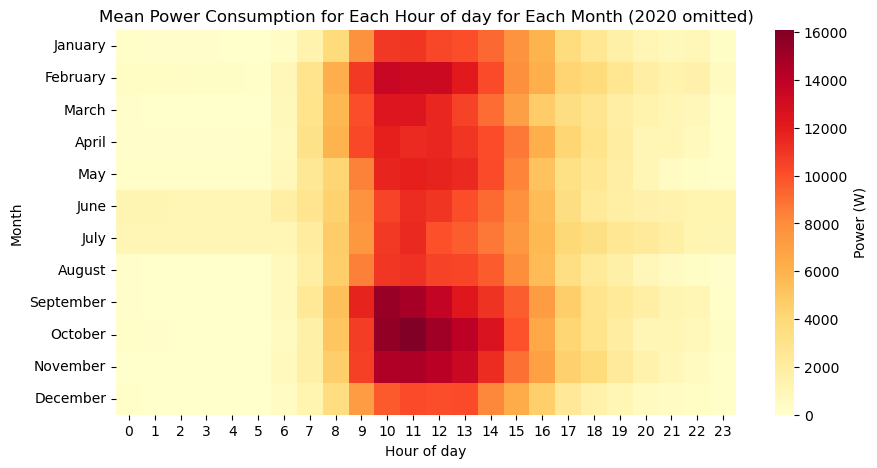

In [5]:
# we want a heatmap that shows the power consumption for each hour of the day for each month of the year

# June 2024 is omitted because not complete
mask = (df_new["recordTimestamp"] < "2024-06-01") & (
    df_new["recordTimestamp"].dt.year > 2020
)

if frequency_mode == "hour_of_day":
    df_for_each_month_and_hour = df_new[mask].groupby(
        [df_new["recordTimestamp"].dt.month, df_new["recordTimestamp"].dt.hour]
    )["totalPower"]
elif frequency_mode == "day_of_week":
    df_for_each_month_and_hour = df_new[mask].groupby(
        [df_new["recordTimestamp"].dt.month, df_new["recordTimestamp"].dt.day_of_week]
    )["totalPower"]

if power_mode == "max":
    df_for_each_month_and_hour = df_for_each_month_and_hour.max()
elif power_mode == "mean":
    df_for_each_month_and_hour = df_for_each_month_and_hour.mean()

df_for_each_month_and_hour = df_for_each_month_and_hour.unstack()

df_for_each_month_and_hour.index.rename("Month", inplace=True)
# write month as a string
df_for_each_month_and_hour.index = df_for_each_month_and_hour.index.map(
    lambda x: pd.Timestamp(year=2024, month=x, day=1).strftime("%B")
)

# plot the heatmap
fig, ax = plt.subplots(figsize=(10, 5))

# Create the heatmap
sns.heatmap(
    df_for_each_month_and_hour,
    cmap=color_code,
    cbar_kws={"label": "Power (W)"},
    ax=ax,
)

# Add titles and labels
plt.title(
    f"{power_mode.capitalize()} Power Consumption for Each {frequency_mode.replace('_', ' ').capitalize()} for Each Month (2020 omitted)"
)
plt.xlabel(f"{frequency_mode.replace('_', ' ').capitalize()}")
plt.ylabel("Month")

# Display the plot
plt.show()

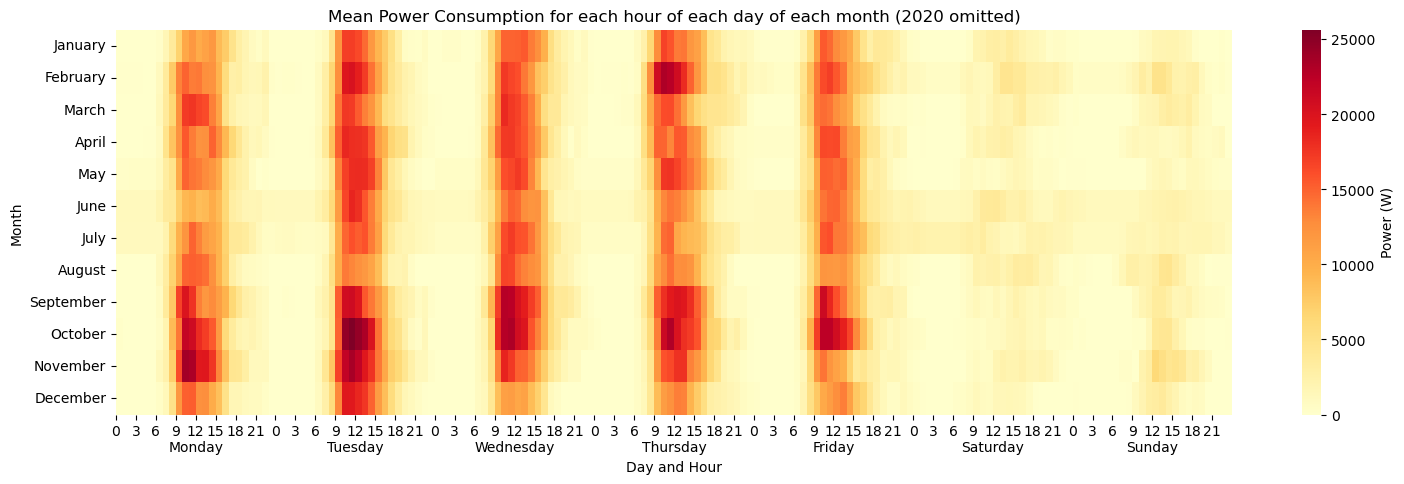

In [6]:
df_test = df_new[mask].groupby(
    [
        df_new["recordTimestamp"].dt.month,
        df_new["recordTimestamp"].dt.hour,
        df_new["recordTimestamp"].dt.day_of_week,
    ]
)["totalPower"]

if power_mode == "max":
    df_test = df_test.max()
elif power_mode == "mean":
    df_test = df_test.mean()

df_test = df_test.unstack().unstack()

# write month as a string
df_test.index = df_test.index.map(
    lambda x: pd.Timestamp(year=2024, month=x, day=1).strftime("%B")
)

df_all = pd.DataFrame()
for i in range(7):
    df_day_i = df_test.loc[:, i]
    df_day_i.columns = pd.MultiIndex.from_tuples(
        [
            (pd.Timestamp(year=2024, month=12, day=i + 2).strftime("%A"), col)
            for col in df_day_i.columns
        ]
    )
    df_all = pd.concat([df_all, df_day_i], axis=1)

# plot the heatmap
fig, ax = plt.subplots(figsize=(18, 5))

# Create the heatmap
sns.heatmap(
    df_all,
    cmap=color_code,
    cbar_kws={"label": "Power (W)"},
    ax=ax,
)

# Set the number of ticks
label_indices = np.arange(0, len(df_all.columns), 3)
ax.set_xticks(label_indices)

labels = df_all.columns[label_indices]
# Customize the tick labels to show two levels
ax.set_xticklabels(
    [f"{hour}\n{day}" if hour == 12 else f"{hour}" for day, hour in labels], rotation=0
)

# Add titles and labels
# Add titles and labels
plt.title(
    f"{power_mode.capitalize()} Power Consumption for each hour of each day of each month (2020 omitted)"
)
plt.xlabel("Day and Hour")
plt.ylabel("Month")

# Display the plot
plt.show()

# Data windowing

In [91]:
df_train, df_test = train_test_split(df_old, fraction_in_train=0.8)  # type: ignore
normalize_params = get_train_min_and_max(df_train)

In [93]:
x_dim = 32
lookahead = 8
w1 = WindowGenerator(
    input_width=x_dim,
    label_width=x_dim,
    shift=lookahead,
    train_df=feature_engineering(df_train, normalize_parameters=normalize_params),
    test_df=feature_engineering(df_test, normalize_parameters=normalize_params),
    label_columns=["power", "date"],
    overlapping_windows=False,
    batch_size=1000,
)

w1

Total window size: 40
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
Label indices: [ 8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
 32 33 34 35 36 37 38 39]
Label column name(s): ['power', 'date']

For the second window, inputs will start at 8 and end at 39,
Use the .plot function to see the data.

In [62]:
item_number = 0
inputs_first_batch = next(iter(w1.train))[0]
start = pd.to_datetime(inputs_first_batch[item_number][0][0], unit="s")
end = pd.to_datetime(inputs_first_batch[item_number][-1][0], unit="s")

print(f"Start: {start}, end: {end} of item {item_number}")

Start: 2022-01-01 00:00:00, end: 2022-01-01 03:44:00 of item 0


In [ ]:
item_number = 1  # works if batch size is >=2
inputs_first_batch = next(iter(w1.train))[0]
start = pd.to_datetime(inputs_first_batch[item_number][0][0], unit="s")
end = pd.to_datetime(inputs_first_batch[item_number][-1][0], unit="s")

print(f"Start: {start}, end: {end} of item {item_number}")

In [7]:
df_train.groupby(df_train["date"].dt.minute).count()

,date,power,workday
date,,,
0,15591,15591,15591
15,15591,15591,15591
30,15590,15590,15590
45,15590,15590,15590


In [72]:
df_train_eng = feature_engineering(df_train, normalize_parameters=normalize_params)

In [73]:
reverse_feature_engineering(
    df_train_eng, normalize_parameters=normalize_params
).groupby(
    reverse_feature_engineering(df_train_eng, normalize_parameters=normalize_params)[
        "date"
    ].dt.minute
).count()

,date,power,workday,time_window,Week sin,Week cos
date,,,,,,
0,15591,15591,15591,15591,15591,15591
15,15590,15590,15590,15590,15590,15590
30,15590,15590,15590,15590,15590,15590
45,15590,15590,15590,15590,15590,15590


In [74]:
reverse_feature_engineering(df_train_eng)

,date,power,workday,time_window,Week sin,Week cos
0,2022-01-01 00:00:00,0.000000,0,0,0.974928,-0.222521
1,2022-01-01 00:15:00,0.000000,0,0,0.972805,-0.231627
2,2022-01-01 00:30:00,0.000000,0,0,0.970597,-0.240712
3,2022-01-01 00:45:00,0.000000,0,0,0.968304,-0.249776
4,2022-01-01 01:00:00,0.000000,0,0,0.965926,-0.258819
...,...,...,...,...,...,...
62356,2023-10-12 13:00:00,0.656178,1,3,0.467269,0.884115
62357,2023-10-12 13:15:00,0.526186,1,3,0.475515,0.879708
62358,2023-10-12 13:30:00,0.526186,1,3,0.483719,0.875223
62359,2023-10-12 13:45:00,0.399166,1,3,0.491881,0.870662


In [10]:
flat_inputs, flat_labels = w1.flatten_dataset(
    w1.train, ["power"], ["workday", "time_window"], label_cols_to_flatten=["date"]
)

In [ ]:
for batch in w1.train:
    inputs, labels = batch
    print(f"inputs.shape: {inputs.shape}, labels.shape: {labels.shape}")

In [29]:
w1.column_indices

{'date': 0,
 'power': 1,
 'workday': 2,
 'time_window': 3,
 'Day sin': 4,
 'Day cos': 5,
 'Year sin': 6,
 'Year cos': 7}

In [45]:
dataset = w1.convert_to_torch_dataset(w1.train, ["workday", "time_window"], ["power"])

In [48]:
inputs, outputs = dataset.get_full_data()

In [50]:
inputs.shape

torch.Size([62331, 16, 2])

In [17]:
flat_inputs, flat_labels = w1.flatten_dataset(
    w1.train, ["power"], ["workday", "time_window"], label_cols_to_flatten=["date"]
)

In [43]:
w1.label_columns_indices

{'power': 0, 'date': 1}

In [27]:
x_dates, y_dates = w1.flatten_dataset(
    w1.train, cols_to_flatten=["date"], label_cols_to_flatten=["date"]
)

In [18]:
flat_inputs_3

,power_0,power_1,power_2,power_3,power_4,power_5,power_6,power_7,power_8,power_9,power_10,power_11,power_12,power_13,power_14,power_15,workday,time_window
0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62326,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.241620,0.241620,0.371612,0.409363,0.409363,0.409363,0.509513,1.0,2.0
62327,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.241620,0.241620,0.371612,0.409363,0.409363,0.409363,0.509513,0.620671,1.0,2.0
62328,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.241620,0.241620,0.371612,0.409363,0.409363,0.409363,0.509513,0.620671,0.620671,1.0,2.0
62329,0.0,0.0,0.0,0.0,0.0,0.00000,0.24162,0.241620,0.371612,0.409363,0.409363,0.409363,0.509513,0.620671,0.620671,0.620671,1.0,2.0


In [68]:
columns = ["time_window", "workday"]
one_hot_length = flat_inputs[columns].apply(lambda x: len(x.unique()))
# we do not want to encode boolean arrays (with only two values)
if one_hot_length[one_hot_length <= 2].shape[0] > 0:
    columns_to_ignore = one_hot_length[one_hot_length <= 2].index.tolist()
    print(
        f"WARNING: Column(s) {columns_to_ignore} are boolean (only two possible values) and will not be one-hot encoded"
    )
    columns = [col for col in columns if col not in columns_to_ignore]

NameError: name 'flat_inputs' is not defined

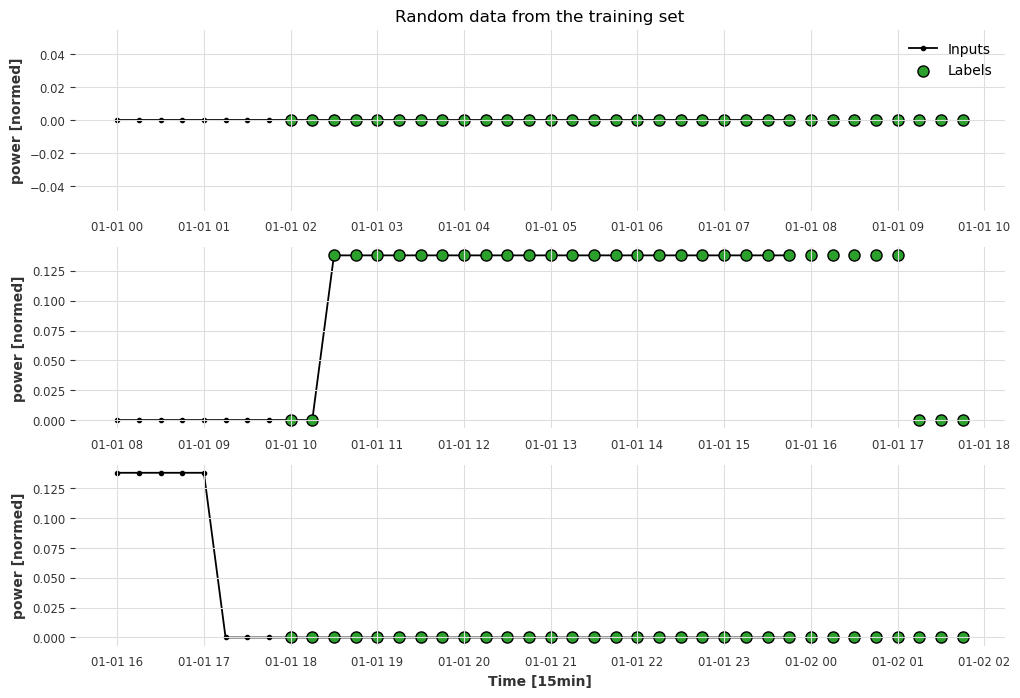

In [84]:
w1.plot()

In [6]:
# convert the date to a timestamp
df_train_for_tf = df_train.copy()

df_train_for_tf["date"] = df_train_for_tf["date"].astype("int64") // 10**9

# Tests

### Sktime tests

In [85]:
from sktime.datasets import load_airline
from sktime.forecasting.fbprophet import Prophet
from sktime.utils.plotting import plot_series

In [22]:
y = load_airline()

In [23]:
# this is the data known in December 1957
y_train = y[:-36]

In [39]:
forecaster = Prophet(
    freq="1M",
    seasonality_mode="multiplicative",
    # n_changepoints=int(len(y_train) / 12),
    # add_country_holidays={"country_name": "US"},
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    # the three growth arguments go together.
    # Don't forget that the data is normalize (btw 0 and 1)
    # growth_floor=0,
    # growth_cap=1,
    # growth="logistic",
)

In [ ]:
forecaster.fit(y=y_train)

In [41]:
lookahead = 12
y_pred = forecaster.predict(fh=np.arange(1, lookahead + 1))

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

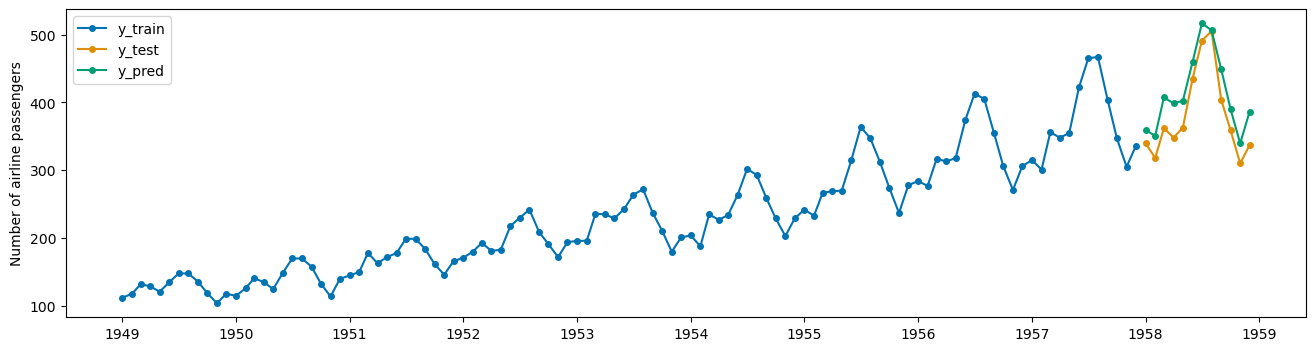

In [42]:
plot_series(
    y_train,
    y[-36 : -36 + lookahead],
    y_pred,
    labels=["y_train", "y_test", "y_pred"],
)

In [ ]:
y.loc[pd.timedelta_range(y.index[0], y.index[0] + pd.Timedelta(days=40))]

### Darts tests

In [94]:
from darts.models import NaiveSeasonal
from darts.metrics import mse
from darts.models import (
    ExponentialSmoothing,
)  # very long... (didn't run a less than 12 hours)
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from darts import concatenate
from darts.utils.timeseries_generation import datetime_attribute_timeseries as dt_attr
from darts.models import BlockRNNModel
from darts.models import TCNModel
from darts.models import TransformerModel
from darts.models import TFTModel
from darts.models import ARIMA
from darts.models import Prophet as ProphetDarts

In [96]:
LOOKAHEAD = 16
X_DIM = 96

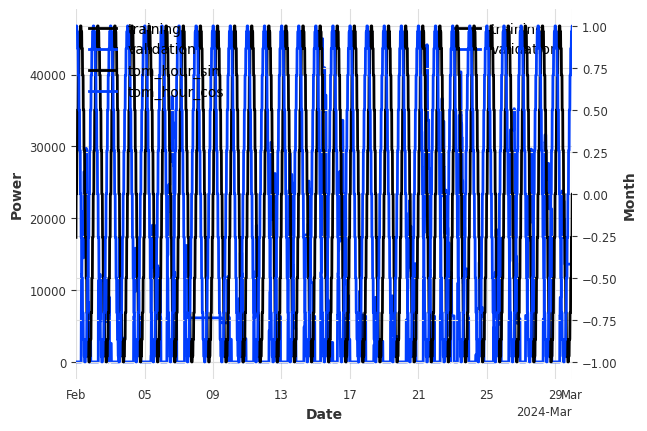

In [97]:
series = TimeSeries.from_dataframe(df_old, time_col="date", value_cols="power")
train, val = series.split_before(pd.Timestamp("2023-09-01"))

fig, ax = plt.subplots()

train.plot(label="training", ax=ax)
val.plot(label="validation", ax=ax)

# Plot the month on a secondary axis
ax2 = ax.twinx()
dt_attr(series, "hour", dtype=np.float32, cyclic=True).plot(label="tom", ax=ax2)

ax.set_xlim(pd.Timestamp("2024-02-01"), pd.Timestamp("2024-03-01"))

# Set labels for the axes
ax.set_xlabel("Date")
ax.set_ylabel("Power")
ax2.set_ylabel("Month")

# Create a legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

# Display the plot
plt.show()

In [98]:
def get_covariates(ts: TimeSeries) -> TimeSeries:
    series_cov = concatenate(
        [
            dt_attr(ts, "day_of_week", dtype=np.float32, cyclic=True),
            dt_attr(ts, "day_of_year", dtype=np.float32, cyclic=True),
            dt_attr(ts, "hour", dtype=np.float32, cyclic=True),
        ],
        axis="component",
    )
    # default scaler is min-max scaler
    series_cov = Scaler().fit_transform(series_cov)
    return series_cov

In [99]:
def eval_model(
    model, series: TimeSeries, mode: Literal["statistical", "deepl"]
) -> TimeSeries:
    # get train, validation and test sets
    fraction_in_train = 0.7
    fraction_in_val = 0.2
    data_length = len(series)
    split_train_index = int(data_length * fraction_in_train)
    train = series[: split_train_index - 1]
    split_val_index = int(data_length * (fraction_in_train + fraction_in_val))
    val = series[split_train_index : split_val_index - 1]
    test = series[split_val_index:]

    # scale data (min max scaling)
    scaler = Scaler()
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(val)
    test_scaled = scaler.transform(test)

    # covariates
    covariates = get_covariates(series)

    if mode == "statistical":
        model.fit(train_scaled)

    elif mode == "deepl":
        model.fit(
            train_scaled,
            past_covariates=covariates,
            val_series=val_scaled,
            val_past_covariates=covariates,
            epochs=3,
            verbose=True,
        )

    hfc_params = {
        "series": test_scaled,
        "forecast_horizon": LOOKAHEAD,
        "verbose": True,
    }
    if mode == "deepl":
        hfc_params["retrain"] = False
        hfc_params["past_covariates"] = covariates
    forecast = model.historical_forecasts(last_points_only=True, **hfc_params)
    forecast = scaler.inverse_transform(forecast)

    print(f"model {model} obtains RMSE: {np.sqrt(mse(test, forecast)):.2f}")

    return forecast


def plot_forecast(
    forecast: TimeSeries,
    series: TimeSeries,
    start_date=pd.Timestamp("2024-02-01"),
    end_date=pd.Timestamp("2024-03-01"),
):
    forecast = forecast.resample("15min")
    print(f"RMSE after resampling: {np.sqrt(mse(series, forecast)):.2f}")
    fig, ax = plt.subplots()
    series.plot(label="actual", ax=ax)
    forecast.plot(label="forecast", ax=ax)
    ax.set_xlim(start_date, end_date)

    plt.show()

  0%|          | 0/1910 [00:00<?, ?it/s]

model NaiveSeasonal(K=24) obtains RMSE: 8557.60
RMSE after resampling: 8605.55


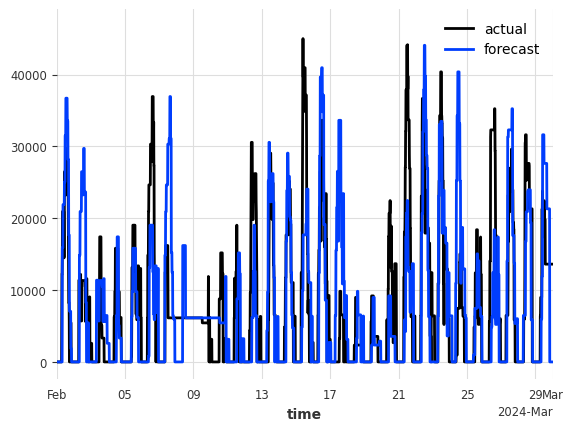

In [100]:
downsample_hours = 1
model = NaiveSeasonal(K=int(96 / (4 * downsample_hours)))


forecast = eval_model(
    model, series.resample(f"{downsample_hours}h"), mode="statistical"
)


plot_forecast(forecast, series)

c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  0%|          | 0/363 [00:00<?, ?it/s]

c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

model ARIMA(p=1, d=0, q=1, seasonal_order=(2, 1, 2, 6)) obtains RMSE: 7293.92
RMSE after resampling: 8685.22


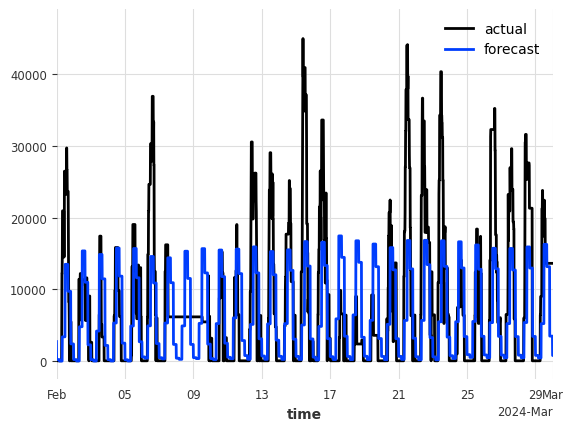

In [54]:
downsample_hours = 4
model = ARIMA(p=1, d=0, q=1, seasonal_order=(2, 1, 2, int(96 / (4 * downsample_hours))))
forecast = eval_model(
    model, series.resample(freq=f"{downsample_hours}h"), mode="statistical"
)
plot_forecast(forecast, series)

12:07:33 - cmdstanpy - INFO - Chain [1] start processing
12:07:33 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/877 [00:00<?, ?it/s]

12:07:34 - cmdstanpy - INFO - Chain [1] start processing
12:07:34 - cmdstanpy - INFO - Chain [1] done processing
12:07:34 - cmdstanpy - INFO - Chain [1] start processing
12:07:34 - cmdstanpy - INFO - Chain [1] done processing
12:07:34 - cmdstanpy - INFO - Chain [1] start processing
12:07:34 - cmdstanpy - INFO - Chain [1] done processing
12:07:35 - cmdstanpy - INFO - Chain [1] start processing
12:07:35 - cmdstanpy - INFO - Chain [1] done processing
12:07:35 - cmdstanpy - INFO - Chain [1] start processing
12:07:35 - cmdstanpy - INFO - Chain [1] done processing
12:07:35 - cmdstanpy - INFO - Chain [1] start processing
12:07:35 - cmdstanpy - INFO - Chain [1] done processing
12:07:35 - cmdstanpy - INFO - Chain [1] start processing
12:07:36 - cmdstanpy - INFO - Chain [1] done processing
12:07:36 - cmdstanpy - INFO - Chain [1] start processing
12:07:36 - cmdstanpy - INFO - Chain [1] done processing
12:07:36 - cmdstanpy - INFO - Chain [1] start processing
12:07:36 - cmdstanpy - INFO - Chain [1]

model Prophet() obtains RMSE: 8552.13
RMSE after resampling: 8983.97


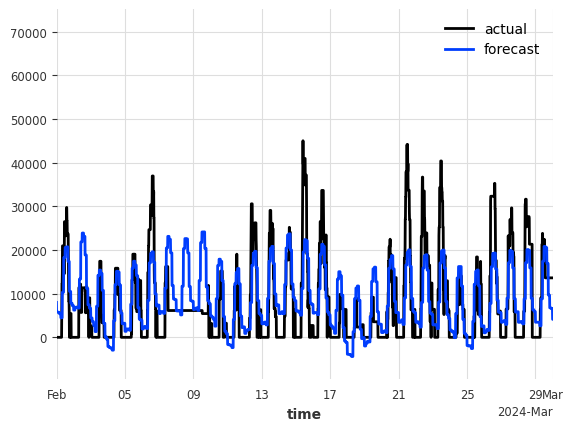

In [55]:
downsample_hours = 2
model = ProphetDarts(
    # There are already seasonalities included by default.
    # Below is how to define some custom ones but it is actually not needed
    # add_seasonalities=[
    #     {
    #         "name": "daily_custom",  # (name of the seasonality component),
    #         "seasonal_periods": 96
    #         / (4 * downsample_hours),  # (nr of steps composing a season),
    #         "fourier_order": 3,  # (number of Fourier components to use),
    #     },
    #     {
    #         "name": "weekly_custom",  # (name of the seasonality component),
    #         "seasonal_periods": 96
    #         * 7
    #         / (4 * downsample_hours),  # (nr of steps composing a season),
    #         "fourier_order": 3,  # (number of Fourier components to use),
    #     },
    # ],
)
forecast = eval_model(
    model, series.resample(freq=f"{downsample_hours}h"), mode="statistical"
)
plot_forecast(forecast, series)

In [101]:
deepl_kwargs = {"log_tensorboard": True}

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 82.9 K | train
-------------------------------------------------------------
78.7 K    Trainable params
4.2 K     Non-trainable params
82.9 K    Total params
0.332     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

model NBEATSModel(num_stacks=3, num_layers=2, layer_widths=32, input_chunk_length=96, output_chunk_length=16, log_tensorboard=True) obtains RMSE: 5633.41
RMSE after resampling: 5633.41


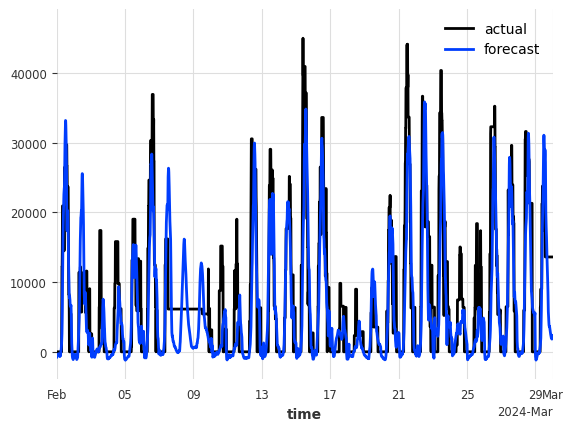

In [102]:
model = NBEATSModel(
    input_chunk_length=X_DIM,
    output_chunk_length=LOOKAHEAD,
    num_stacks=3,
    num_layers=2,
    layer_widths=32,
    **deepl_kwargs
)

forecast = eval_model(model, series, mode="deepl")


plot_forecast(forecast, series)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 5.2 K  | train
6 | fc              | Sequential       | 528    | train
-------------------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

model BlockRNNModel(model=LSTM, hidden_dim=32, input_chunk_length=96, output_chunk_length=16, log_tensorboard=True) obtains RMSE: 5475.54
RMSE after resampling: 5475.54


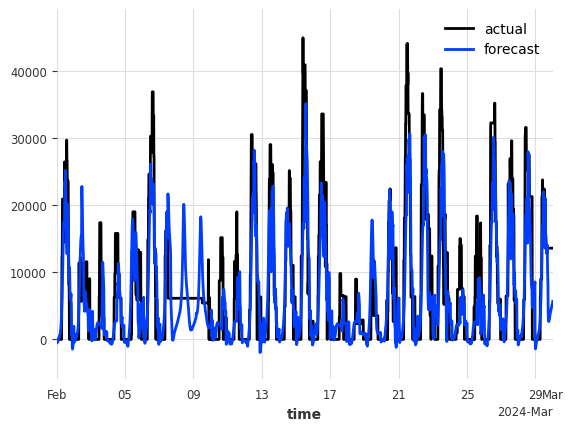

In [103]:
model = BlockRNNModel(
    input_chunk_length=X_DIM,
    output_chunk_length=LOOKAHEAD,
    model="LSTM",
    hidden_dim=32,
    n_rnn_layers=1,
    **deepl_kwargs
)

forecast = eval_model(model, series, mode="deepl")

plot_forecast(forecast, series)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 1.1 K  | train
-------------------------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

model TCNModel(num_filters=6, input_chunk_length=96, output_chunk_length=16, log_tensorboard=True) obtains RMSE: 5326.56
RMSE after resampling: 5326.56


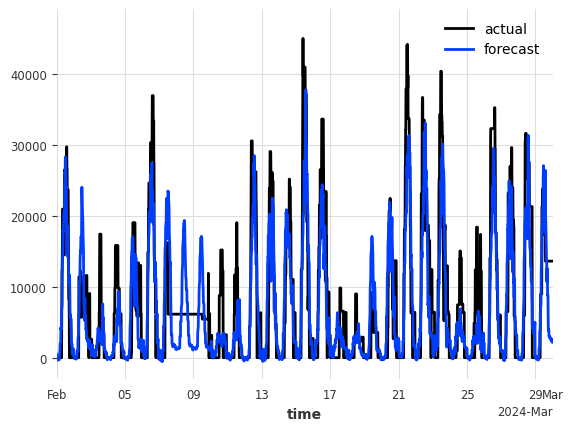

In [104]:
model = TCNModel(
    input_chunk_length=X_DIM,
    output_chunk_length=LOOKAHEAD,
    num_filters=6,
    **deepl_kwargs
)

forecast = eval_model(model, series, mode="deepl")

plot_forecast(forecast, series)

c:\ProgramData\anaconda3\envs\slrp-ev\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | MetricCollection    | 0      | train
5 | encoder             | Linear       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

model TransformerModel(nhead=2, dim_feedforward=64, input_chunk_length=192, output_chunk_length=96, log_tensorboard=True) obtains RMSE: 6840.18
RMSE after resampling: 6840.18


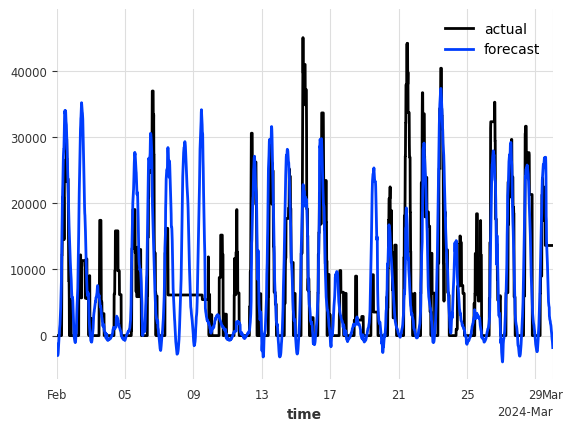

In [59]:
model = TransformerModel(
    input_chunk_length=X_DIM,
    output_chunk_length=LOOKAHEAD,
    dim_feedforward=64,
    nhead=2,  # default is 4
    **deepl_kwargs
)

forecast = eval_model(model, series, mode="deepl")

plot_forecast(forecast, series)

In [60]:
model = TFTModel(
    input_chunk_length=X_DIM,
    output_chunk_length=LOOKAHEAD,
    hidden_size=16,
    **deepl_kwargs
)

forecast = eval_model(model, series, mode="deepl")

plot_forecast(forecast, series)

ValueError: TFTModel requires future covariates. The model applies multi-head attention queries on future inputs. Consider specifying a future encoder with `add_encoders` or setting `add_relative_index` to `True` at model creation (read TFT model docs for more information). These will automatically generate `future_covariates` from indexes.


ValueError: TFTModel requires future covariates. The model applies multi-head attention queries on future inputs. Consider specifying a future encoder with `add_encoders` or setting `add_relative_index` to `True` at model creation (read TFT model docs for more information). These will automatically generate `future_covariates` from indexes.